In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the cleaned data from the previous notebook
df = pd.read_csv('../data/cleaned_reviews.csv')

df

,review_text,rating,date,verified,country,clean_text,sentiment
0,✅Trip Verified| I'm not entirely sure as to wh...,8,2026-05-02,True,T Bayne(United Kingdom)2nd May 2026,trip verified im not entirely sure as to what ...,positive
1,✅Trip Verified| Our first time in the new bu...,8,2026-04-21,True,Kevin Tunnicliffe(United Kingdom)21st April 2026,trip verified our first time in the new busine...,positive
2,✅Trip Verified| Highly commendable again on ...,10,2026-04-09,True,Brian Crockford(United Kingdom)9th April 2026,trip verified highly commendable again on all ...,positive
3,✅Trip Verified| Highly commendable on all fr...,10,2026-04-09,True,Brian Crockford(United Kingdom)9th April 2026,trip verified highly commendable on all fronts...,positive
4,Not Verified| Although the staff on board t...,2,2026-04-06,False,Sarah Harrison(United Kingdom)6th April 2026,not verified although the staff on board the f...,negative
...,...,...,...,...,...,...,...
3990,LHR-FRA-LCY May 2014. LHR-FRA on a 767 row 18....,9,2014-05-11,False,L Matt(United Kingdom)11th May 2014,lhrfralcy may 2014 lhrfra on a 767 row 18 chec...,positive
3991,Rating : 10/10 Cabin Flown Economy Value for M...,10,2014-05-11,False,Colin Pay(United Kingdom)11th May 2014,rating 1010 cabin flown economy value for mone...,positive
3992,2/5/2014 BRU-LHR-JFK. Short flight in business...,9,2014-05-11,False,Jeff Suykerbuyk(Belgium)11th May 2014,252014 brulhrjfk short flight in business from...,positive
3993,08/5/2014 JFK-LHR-BRU. After the perfect outbo...,10,2014-05-11,False,Jeff Suykerbuyk(Belgium)11th May 2014,0852014 jfklhrbru after the perfect outbound f...,positive


## Prepare the data for the model

In [4]:
# X is the input — the review text the model will read
X = df['clean_text']

# y is the target — what the model will predict
y = df['sentiment']

# Split into training set (80%) and test set (20%)
# The model learns from the training set
# and evaluate it on the test set — 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% goes to testing
    random_state=42,     # fixes the random split so results are reproducible
    stratify=y           # ensures each sentiment class is fairly represented in both sets
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 3196
Testing samples:  799


## Train Model A (TF-IDF + Logistic Regression)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# A Pipeline chains steps together so we can run them in one go
# Step 1 — TfidfVectorizer converts review text into numbers the model understands
# Step 2 — LogisticRegression is our classifier that predicts the sentiment
model_a = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,   # only use the 10,000 most common words
        ngram_range=(1, 2),   # consider single words AND pairs of words 
        sublinear_tf=True     # reduces the weight of very common words
    )),
    ('clf', LogisticRegression(
        max_iter=1000,        # maximum number of times the model adjusts itself
        class_weight='balanced', # compensates for the imbalanced dataset 
        random_state=42
    ))
])

# Train the model on the training data
model_a.fit(X_train, y_train)

print("Model A trained successfully!")

Model A trained successfully!


## Evaluate Model A (TF-IDF + Logistic Regression)

MODEL A — TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative       0.81      0.82      0.81       376
     neutral       0.40      0.44      0.42       144
    positive       0.88      0.81      0.84       279

    accuracy                           0.75       799
   macro avg       0.69      0.69      0.69       799
weighted avg       0.76      0.75      0.75       799



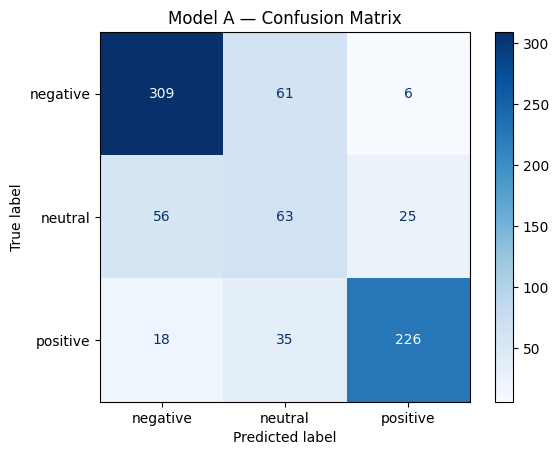

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use the trained model to predict sentiment on the test set
y_pred_a = model_a.predict(X_test)

# classification_report shows precision, recall and F1 score per class
# precision = of all reviews predicted positive, how many actually were?
# recall    = of all actual positive reviews, how many did we catch?
# F1        = balance between precision and recall
print("=" * 50)
print("MODEL A — TF-IDF + Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_pred_a))

# Confusion matrix shows exactly where the model gets confused
# Rows = actual sentiment, Columns = predicted sentiment
cm = confusion_matrix(y_test, y_pred_a, labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap='Blues')
plt.title('Model A — Confusion Matrix')
plt.show()

## Build Model B(VADER baseline)

In [7]:
# pip install vaderSentiment 
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# VADER is a rule-based sentiment tool — it doesn't learn from data
# It uses a built-in dictionary of words with sentiment scores
# We use it as a baseline to compare against our trained model
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    # compound score ranges from -1 (most negative) to +1 (most positive)
    score = analyzer.polarity_scores(text)['compound']

    if score <= -0.2:
        return 'negative'
    elif score >= 0.2:
        return 'positive'
    else:
        return 'neutral'

# Apply VADER to the test set
y_pred_vader = X_test.apply(vader_predict)

print("=" * 50)
print("MODEL B — VADER Baseline")
print("=" * 50)
print(classification_report(y_test, y_pred_vader))

MODEL B — VADER Baseline
              precision    recall  f1-score   support

    negative       0.80      0.70      0.75       376
     neutral       0.19      0.05      0.08       144
    positive       0.59      0.92      0.72       279

    accuracy                           0.66       799
   macro avg       0.53      0.56      0.52       799
weighted avg       0.62      0.66      0.62       799



## Compare both models

In [8]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for each model
acc_a     = accuracy_score(y_test, y_pred_a)
acc_vader = accuracy_score(y_test, y_pred_vader)

# Display a  comparison table
comparison = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression', 'VADER Baseline'],
    'Accuracy': [f"{acc_a*100:.1f}%", f"{acc_vader*100:.1f}%"]
})

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(comparison.to_string(index=False))
print("\nConclusion: TF-IDF + LR learns from actual BA reviews")
print("VADER uses generic rules not tuned to airline language")

MODEL COMPARISON
                       Model Accuracy
TF-IDF + Logistic Regression    74.8%
              VADER Baseline    66.0%

Conclusion: TF-IDF + LR learns from actual BA reviews
VADER uses generic rules not tuned to airline language


## Test model on a made up review

In [9]:
# Test the model on a made-up review to see it working in real time

test_reviews = [
    "The flight was delayed 4 hours and the staff were incredibly rude.",
    "Excellent service, comfortable seats and the food was surprisingly good.",
    "Average experience, nothing special but nothing terrible either."
]

for review in test_reviews:
    prediction = model_a.predict([review])[0]
    print(f"Review:    {review}")
    print(f"Predicted: {prediction.upper()}")
    print("-" * 60)

Review:    The flight was delayed 4 hours and the staff were incredibly rude.
Predicted: NEGATIVE
------------------------------------------------------------
Review:    Excellent service, comfortable seats and the food was surprisingly good.
Predicted: POSITIVE
------------------------------------------------------------
Review:    Average experience, nothing special but nothing terrible either.
Predicted: NEGATIVE
------------------------------------------------------------


# Save trained model

In [10]:
import pickle
import os

# Create the models folder 
os.makedirs('../models', exist_ok=True)

# Save the trained model to a file using pickle
with open('../models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(model_a, f)

print("Model saved to models/sentiment_model.pkl")

Model saved to models/sentiment_model.pkl
